In [ ]:
!pip install --upgrade ipywidgets
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
import warnings
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
device = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

1. Генерация данных для регрессии

In [ ]:
def generate_data_1(n_samples=500):
    X = (torch.rand(n_samples, 1) * 4) - 2
    X = X[torch.randperm(n_samples)]
    y = X**3 - 2*X + torch.randn_like(X) * 0.2
    return X, y

def generate_data_2(n_samples=500):
    X = (torch.rand(n_samples, 1) * 10) - 5
    X = X[torch.randperm(n_samples)]
    y = torch.sin(X) + torch.randn_like(X) * 0.2
    return X, y

def generate_data_3(n_samples=500):
    X = (torch.rand(n_samples, 1) * 6) - 3
    X = X[torch.randperm(n_samples)]
    y = torch.exp(-X**2) + 0.5 * X**2 + torch.randn_like(X) * 0.1
    return X, y

In [ ]:
X_1, y_1= generate_data_1()
X_2, y_2 = generate_data_2()
X_3, y_3 = generate_data_3()

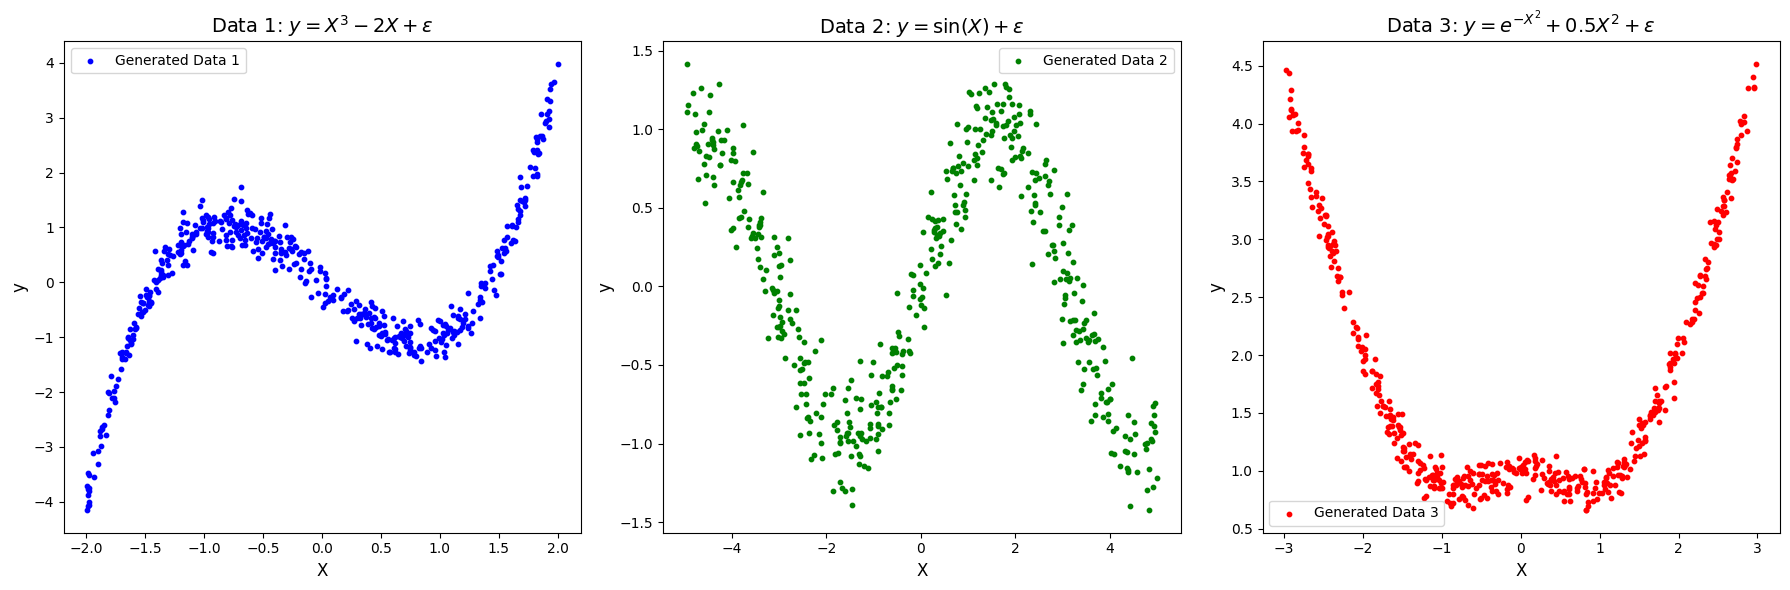

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(X_1, y_1, color='blue', label='Generated Data 1', s=10)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Data 1: $y = X^3 - 2X + \epsilon$', fontsize=14)
axes[0].legend()

axes[1].scatter(X_2, y_2, color='green', label='Generated Data 2', s=10)
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Data 2: $y = \sin(X) + \epsilon$', fontsize=14)
axes[1].legend()

axes[2].scatter(X_3, y_3, color='red', label='Generated Data 3', s=10)
axes[2].set_xlabel('X', fontsize=12)
axes[2].set_ylabel('y', fontsize=12)
axes[2].set_title('Data 3: $y = e^{-X^2} + 0.5X^2 + \epsilon$', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.show()

2. Подготовка данных

In [ ]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        element_X = self.X[idx]
        element_y = self.y[idx]
        return element_X, element_y

In [ ]:
X_1_train, X_1_val, y_1_train, y_1_val = train_test_split(X_1, y_1, test_size=0.2, random_state=42)
X_2_train, X_2_val, y_2_train, y_2_val = train_test_split(X_2, y_2, test_size=0.2, random_state=42)
X_3_train, X_3_val, y_3_train, y_3_val = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [ ]:
train_dataset_1 = MyDataset(
    X=X_1_train,
    y=y_1_train
)
val_dataset_1 = MyDataset(
    X=X_1_val,
    y=y_1_val
)

train_dataset_2 = MyDataset(
    X=X_2_train,
    y=y_2_train
)
val_dataset_2 = MyDataset(
    X=X_2_val,
    y=y_2_val
)

train_dataset_3 = MyDataset(
    X=X_3_train,
    y=y_3_train
)
val_dataset_3 = MyDataset(
    X=X_3_val,
    y=y_3_val
)

3. Регрессионая модель

In [ ]:
class RegressionModel(nn.Module):
    def __init__(self, use_batchnorm=False, use_dropout=False):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.bn1 = nn.BatchNorm1d(64) if use_batchnorm else nn.Identity()
        self.dropout1 = nn.Dropout(0.3) if use_dropout else nn.Identity()

        self.fc2 = nn.Linear(64, 64)
        self.bn2 = nn.BatchNorm1d(64) if use_batchnorm else nn.Identity()
        self.dropout2 = nn.Dropout(0.3) if use_dropout else nn.Identity()

        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

4. Train Loop

In [ ]:
def train(model, num_epochs, train_dataloder, val_dataloder):
    train_losses = []
    val_losses = []
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        train_running_loss = 0
        model.train()
        for X_batch, y_batch in train_dataloder:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_running_loss += loss.item()
        train_losses.append(train_running_loss / len(train_dataloder))

        val_running_loss = 0
        model.eval()
        for X_batch, y_batch in val_dataloder:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            with torch.no_grad():
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_running_loss += loss.item()
        val_losses.append(val_running_loss / len(val_dataloder))
        if epoch % 50 == 0 and epoch != 0:
            print(f" Epoch: {epoch-1} | Train Loss: {(train_running_loss / len(train_dataloder)):.4f} | Val Loss {(val_running_loss / len(val_dataloder)):.4f}")
    return train_losses, val_losses

In [ ]:
def plot_results(train_losses, val_losses, batch_size=None, is_batchnorm=None, is_dropout=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    epochs = range(1, len(train_losses) + 1)

    ax.plot(epochs, train_losses, color='blue', label='Train losses', linewidth=2)
    ax.plot(epochs, val_losses, color='red', label='Val losses', linewidth=2)

    ax.set_xlabel('Epochs', fontsize=14)
    ax.set_ylabel('Losses', fontsize=14)
    if batch_size:
        ax.set_title(f'Train and Val losses, batch_size={batch_size}', fontsize=16)

    if is_batchnorm:
        ax.set_title(f'Train and Val losses, BatchNorm available', fontsize=16)

    if is_dropout:
        ax.set_title(f'Train and Val losses, Dropout available', fontsize=16)

    if is_batchnorm and is_dropout:
        ax.set_title(f'Train and Val losses, Dropout & BatchNorm available', fontsize=16)

    if is_batchnorm == False and is_dropout == False:
        ax.set_title(f'Train and Val losses, Dropout & BatchNorm disable', fontsize=16)

    ax.legend()

    plt.show()

5. Только BatchNorm с разным batch_size

In [ ]:
def train_and_evaluate(train_dataset, val_dataset):
    batch_sizes = [8, 16, 32]
    results_batchnorm = {}

    best_batch_size = None
    best_val_loss = float('inf')

    for batch_size in batch_sizes:
        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = RegressionModel(use_batchnorm=True)
        model.to(device)

        train_losses, val_losses = train(
            model=model,
            num_epochs=300,
            train_dataloder=train_dataloader,
            val_dataloder=val_dataloader
        )

        plot_results(train_losses, val_losses, batch_size=batch_size)
        results_batchnorm[batch_size] = (train_losses, val_losses)

        min_val_loss = min(val_losses)
        if min_val_loss < best_val_loss:
            best_val_loss = min_val_loss
            best_batch_size = batch_size

    print(f"Best batch_size: {best_batch_size} with val loss: {best_val_loss}")
    return best_batch_size, best_val_loss, results_batchnorm

 Epoch: 49 | Train Loss: 1.0671 | Val Loss 0.3842
 Epoch: 99 | Train Loss: 0.9912 | Val Loss 0.3764
 Epoch: 149 | Train Loss: 1.0041 | Val Loss 0.4088
 Epoch: 199 | Train Loss: 1.1320 | Val Loss 0.2617
 Epoch: 249 | Train Loss: 1.2032 | Val Loss 0.3695


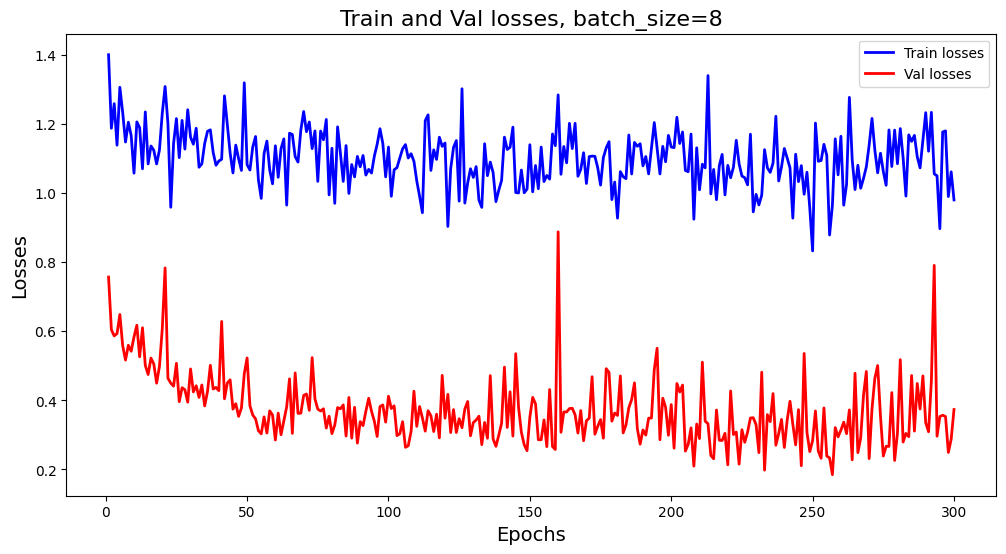

 Epoch: 49 | Train Loss: 0.7833 | Val Loss 0.2757
 Epoch: 99 | Train Loss: 0.6585 | Val Loss 0.1970
 Epoch: 149 | Train Loss: 0.7599 | Val Loss 0.1709
 Epoch: 199 | Train Loss: 0.6423 | Val Loss 0.2837
 Epoch: 249 | Train Loss: 0.4963 | Val Loss 0.2005


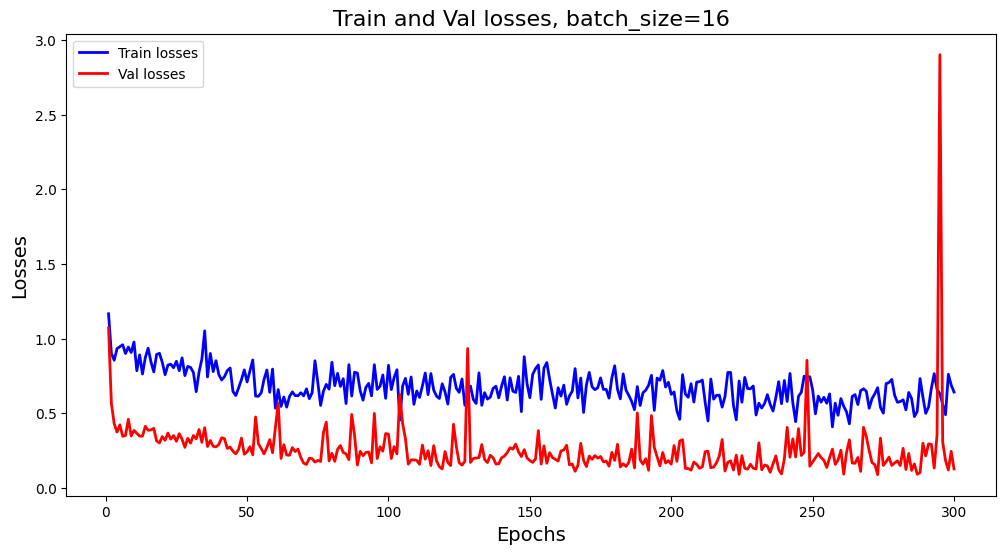

 Epoch: 49 | Train Loss: 0.5322 | Val Loss 0.2630
 Epoch: 99 | Train Loss: 0.3706 | Val Loss 0.1682
 Epoch: 149 | Train Loss: 0.3107 | Val Loss 0.3106
 Epoch: 199 | Train Loss: 0.4171 | Val Loss 0.1226
 Epoch: 249 | Train Loss: 0.2511 | Val Loss 0.0798


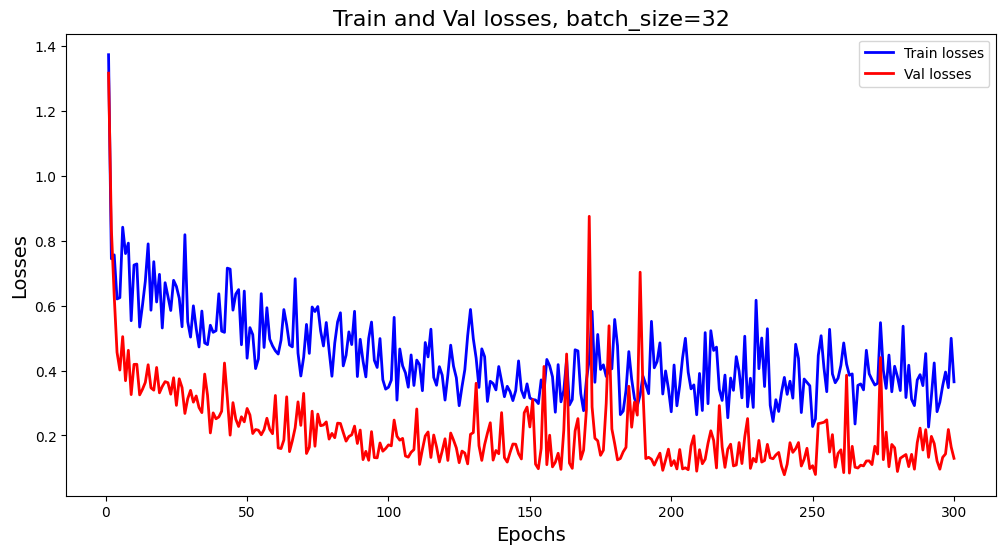

Best batch_size: 32 with val loss: 0.07910958677530289


In [ ]:
best_batch_size_1, best_val_loss_1, results_batchnorm_1 = train_and_evaluate(train_dataset_1, val_dataset_1)

 Epoch: 49 | Train Loss: 0.3958 | Val Loss 0.1744
 Epoch: 99 | Train Loss: 0.3588 | Val Loss 0.1430
 Epoch: 149 | Train Loss: 0.3210 | Val Loss 0.1279
 Epoch: 199 | Train Loss: 0.3930 | Val Loss 0.1482
 Epoch: 249 | Train Loss: 0.4280 | Val Loss 0.1379


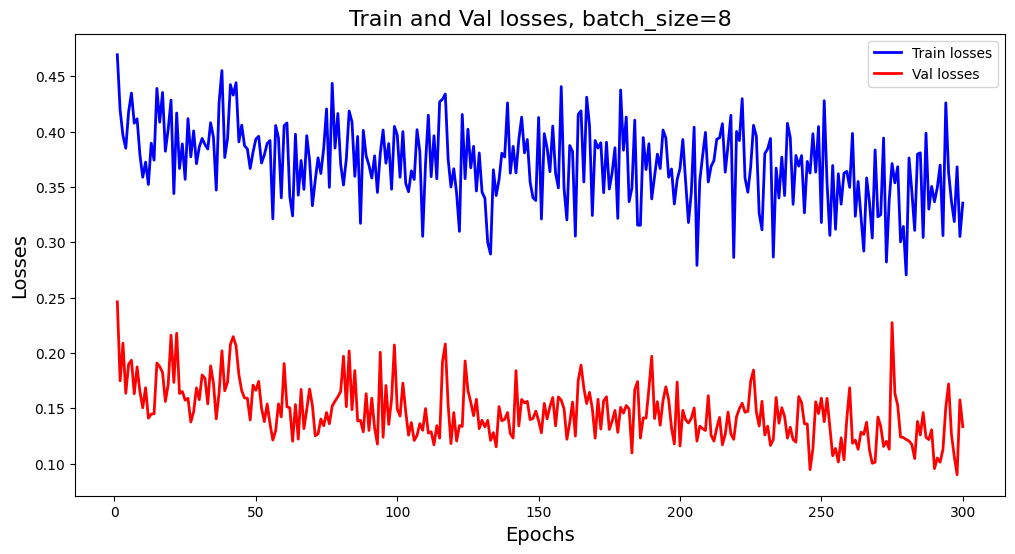

 Epoch: 49 | Train Loss: 0.3194 | Val Loss 0.0738
 Epoch: 99 | Train Loss: 0.2469 | Val Loss 0.0758
 Epoch: 149 | Train Loss: 0.2017 | Val Loss 0.0575
 Epoch: 199 | Train Loss: 0.2424 | Val Loss 0.0771
 Epoch: 249 | Train Loss: 0.2191 | Val Loss 0.0678


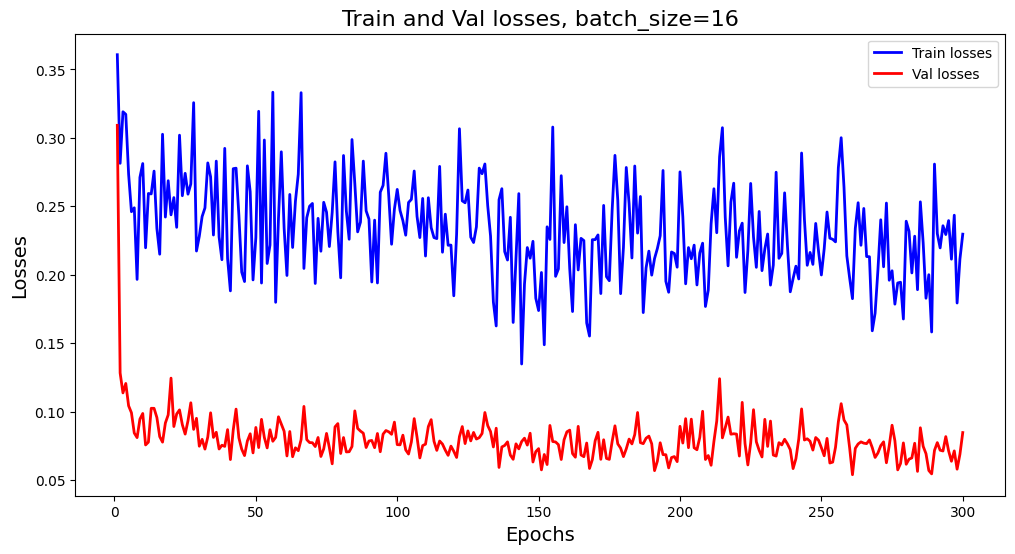

 Epoch: 49 | Train Loss: 0.1915 | Val Loss 0.0895
 Epoch: 99 | Train Loss: 0.1218 | Val Loss 0.0456
 Epoch: 149 | Train Loss: 0.1350 | Val Loss 0.0467
 Epoch: 199 | Train Loss: 0.1423 | Val Loss 0.0442
 Epoch: 249 | Train Loss: 0.1634 | Val Loss 0.0518


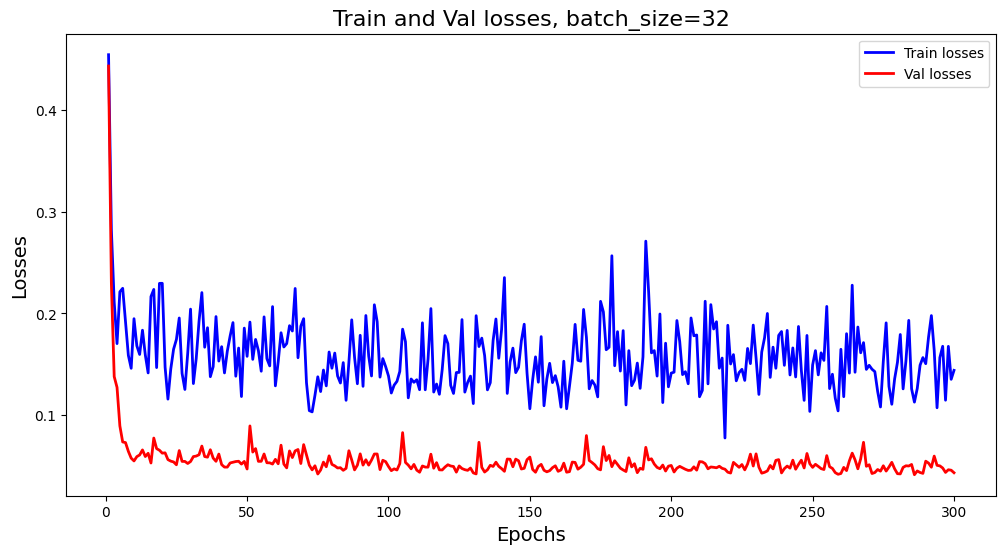

Best batch_size: 32 with val loss: 0.04156949324533343


In [ ]:
best_batch_size_2, best_val_loss_2, results_batchnorm_2 = train_and_evaluate(train_dataset_2, val_dataset_2)

 Epoch: 49 | Train Loss: 0.6901 | Val Loss 0.1850
 Epoch: 99 | Train Loss: 0.5818 | Val Loss 0.1282
 Epoch: 149 | Train Loss: 0.5569 | Val Loss 0.1255
 Epoch: 199 | Train Loss: 0.5174 | Val Loss 0.1030
 Epoch: 249 | Train Loss: 0.5599 | Val Loss 0.0849


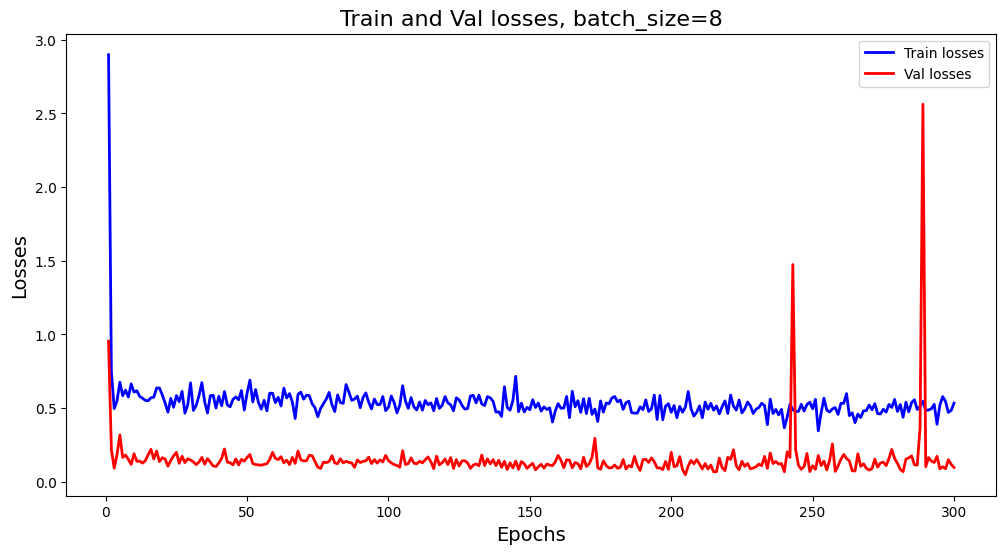

 Epoch: 49 | Train Loss: 0.3275 | Val Loss 0.0773
 Epoch: 99 | Train Loss: 0.3086 | Val Loss 0.0506
 Epoch: 149 | Train Loss: 0.2501 | Val Loss 0.0491
 Epoch: 199 | Train Loss: 0.3184 | Val Loss 0.0422
 Epoch: 249 | Train Loss: 0.3479 | Val Loss 0.0537


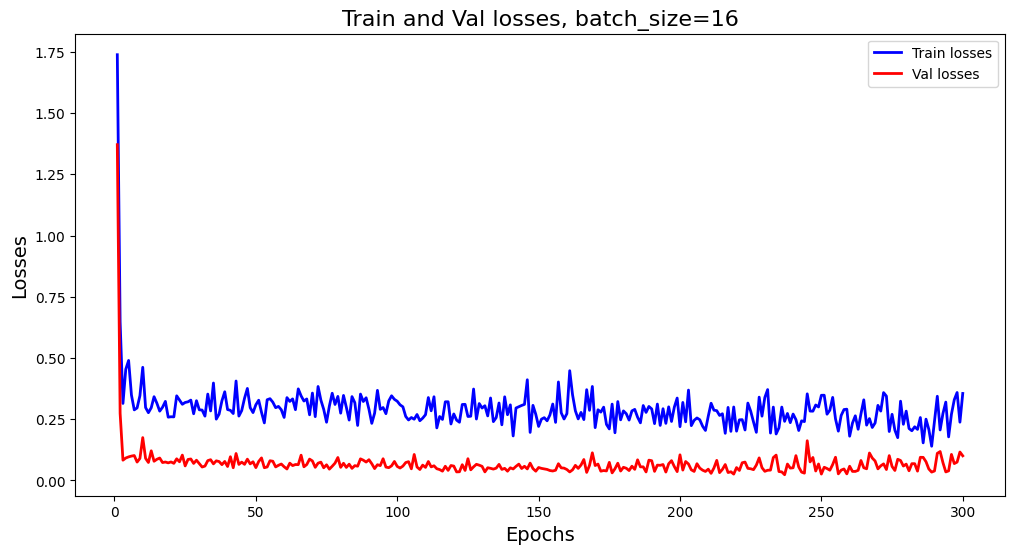

 Epoch: 49 | Train Loss: 0.1197 | Val Loss 0.0498
 Epoch: 99 | Train Loss: 0.1757 | Val Loss 0.0414
 Epoch: 149 | Train Loss: 0.1089 | Val Loss 0.0217
 Epoch: 199 | Train Loss: 0.1545 | Val Loss 0.0320
 Epoch: 249 | Train Loss: 0.1094 | Val Loss 0.0233


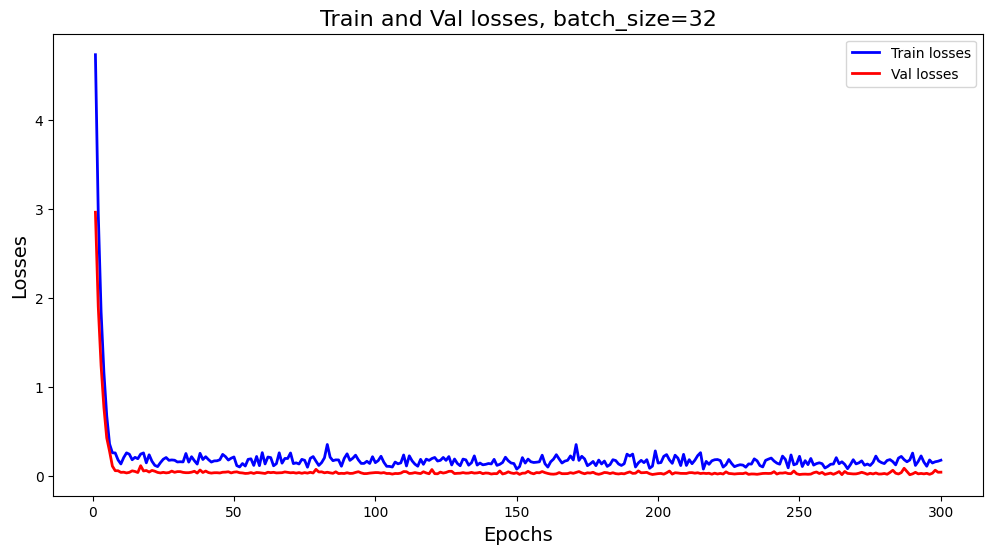

Best batch_size: 32 with val loss: 0.01759961573407054


In [ ]:
best_batch_size_3, best_val_loss_3, results_batchnorm_3 = train_and_evaluate(train_dataset_3, val_dataset_3)

6. Тест все варианты

In [ ]:
train_dataloader_1 = DataLoader(train_dataset_1, batch_size=best_batch_size_1, shuffle=True)
val_dataloader_1 = DataLoader(val_dataset_1, batch_size=best_batch_size_1, shuffle=False)

train_dataloader_2 = DataLoader(train_dataset_2, batch_size=best_batch_size_2, shuffle=True)
val_dataloader_2 = DataLoader(val_dataset_2, batch_size=best_batch_size_2, shuffle=False)

train_dataloader_3 = DataLoader(train_dataset_3, batch_size=best_batch_size_3, shuffle=True)
val_dataloader_3 = DataLoader(val_dataset_3, batch_size=best_batch_size_3, shuffle=False)

In [ ]:
def train_and_evaluate_models(train_dataloader, val_dataloader):
    configs = {
        "No Dropout, No BatchNorm": (RegressionModel(False, False), False, False),
        "BatchNorm Only": (RegressionModel(True, False), True, False),
        "Dropout Only": (RegressionModel(False, True), False, True),
        "BatchNorm + Dropout": (RegressionModel(True, True), True, True)
    }

    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_epochs = 300
    results = {}

    for name, model_bs_dropout_tuple in configs.items():
        model, use_batchnorm, use_dropout = model_bs_dropout_tuple
        model.to(device)

        train_losses, val_losses = train(
            model=model,
            num_epochs=num_epochs,
            train_dataloder=train_dataloader,
            val_dataloder=val_dataloader
        )

        plot_results(train_losses, val_losses, is_batchnorm=use_batchnorm, is_dropout=use_dropout)
        results[name] = (train_losses, val_losses)

    return results

 Epoch: 49 | Train Loss: 0.0524 | Val Loss 0.0441
 Epoch: 99 | Train Loss: 0.0489 | Val Loss 0.0444
 Epoch: 149 | Train Loss: 0.0497 | Val Loss 0.0420
 Epoch: 199 | Train Loss: 0.0463 | Val Loss 0.0445
 Epoch: 249 | Train Loss: 0.0497 | Val Loss 0.0393


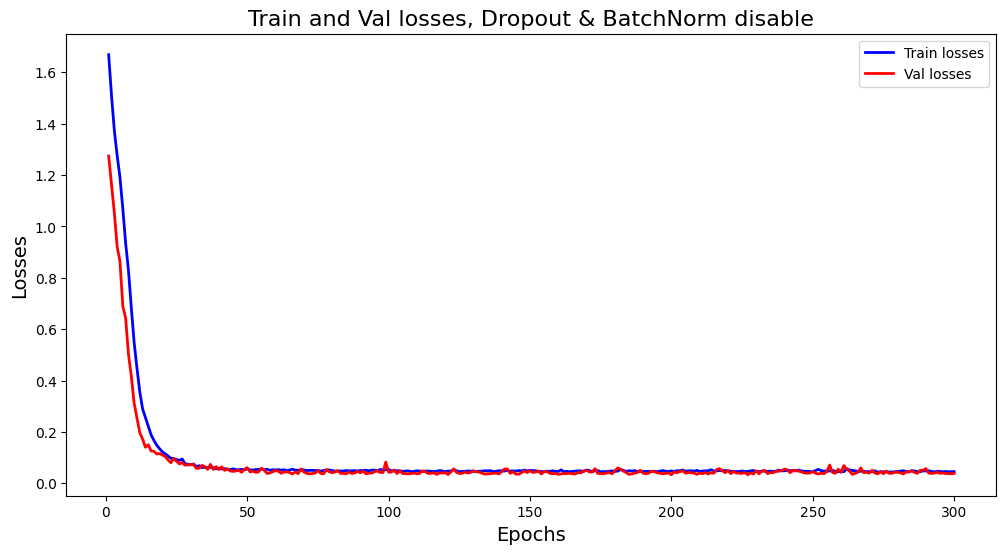

 Epoch: 49 | Train Loss: 0.4620 | Val Loss 0.2461
 Epoch: 99 | Train Loss: 0.5002 | Val Loss 0.1940
 Epoch: 149 | Train Loss: 0.3206 | Val Loss 0.1173
 Epoch: 199 | Train Loss: 0.3306 | Val Loss 0.1136
 Epoch: 249 | Train Loss: 0.3769 | Val Loss 0.0670


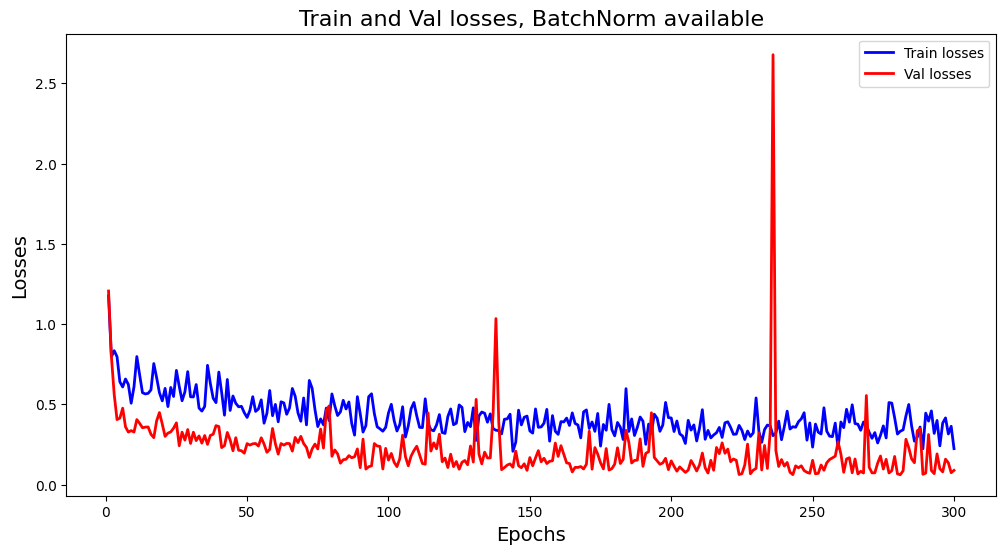

 Epoch: 49 | Train Loss: 0.2933 | Val Loss 0.1088
 Epoch: 99 | Train Loss: 0.1679 | Val Loss 0.0662
 Epoch: 149 | Train Loss: 0.1746 | Val Loss 0.0610
 Epoch: 199 | Train Loss: 0.1442 | Val Loss 0.0489
 Epoch: 249 | Train Loss: 0.1556 | Val Loss 0.0411


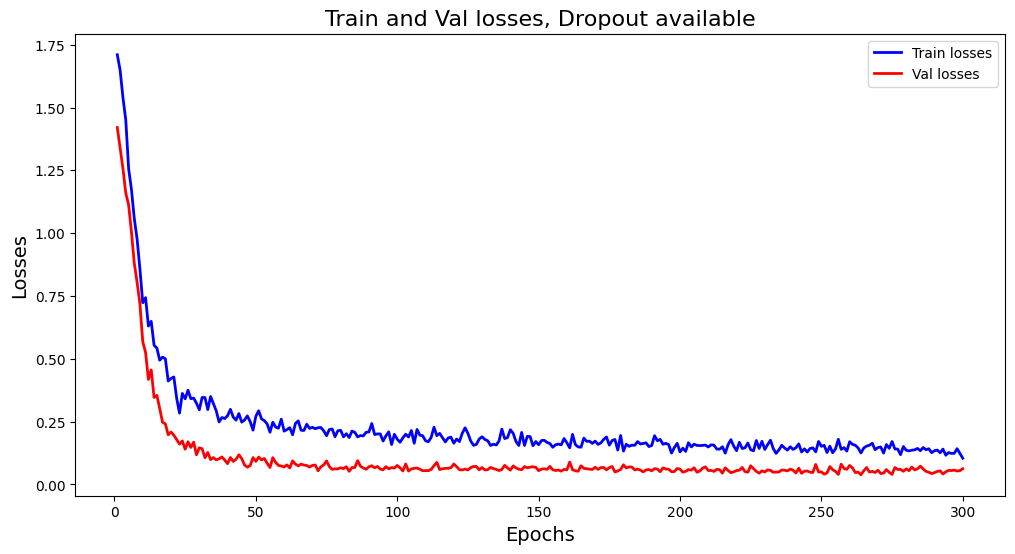

 Epoch: 49 | Train Loss: 0.7579 | Val Loss 0.3155
 Epoch: 99 | Train Loss: 0.6999 | Val Loss 0.2785
 Epoch: 149 | Train Loss: 0.5702 | Val Loss 0.1988
 Epoch: 199 | Train Loss: 0.4349 | Val Loss 0.1536
 Epoch: 249 | Train Loss: 0.5428 | Val Loss 0.2637


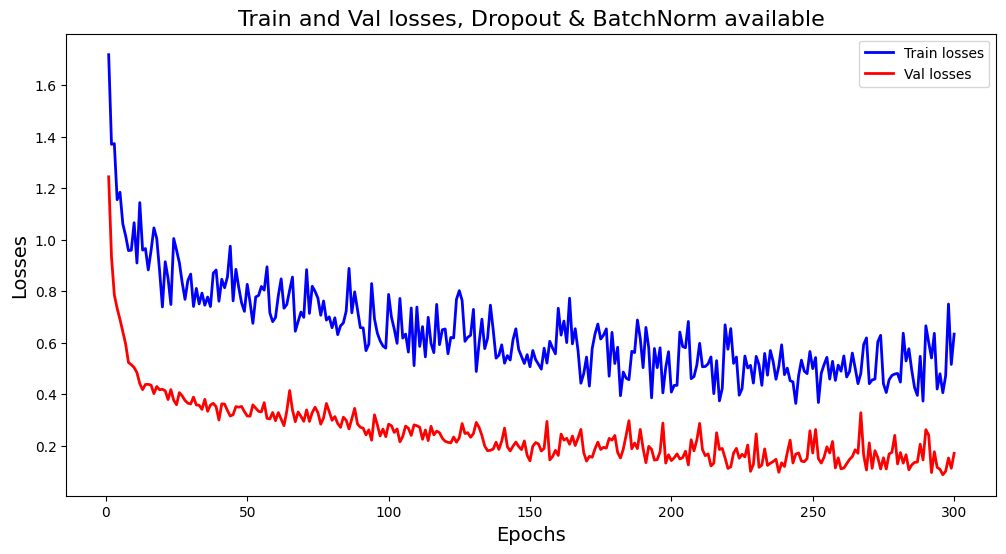

In [ ]:
results_1 = train_and_evaluate_models(train_dataloader_1, val_dataloader_1)

 Epoch: 49 | Train Loss: 0.0472 | Val Loss 0.0436
 Epoch: 99 | Train Loss: 0.0467 | Val Loss 0.0415
 Epoch: 149 | Train Loss: 0.0454 | Val Loss 0.0421
 Epoch: 199 | Train Loss: 0.0417 | Val Loss 0.0427
 Epoch: 249 | Train Loss: 0.0483 | Val Loss 0.0425


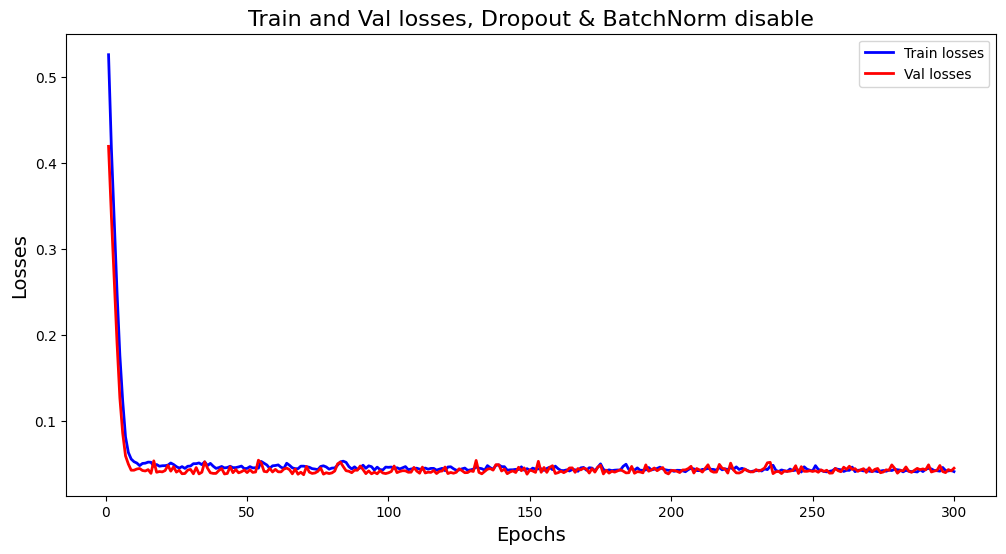

 Epoch: 49 | Train Loss: 0.1502 | Val Loss 0.0513
 Epoch: 99 | Train Loss: 0.1031 | Val Loss 0.0490
 Epoch: 149 | Train Loss: 0.1571 | Val Loss 0.0511
 Epoch: 199 | Train Loss: 0.1365 | Val Loss 0.0457
 Epoch: 249 | Train Loss: 0.1743 | Val Loss 0.0548


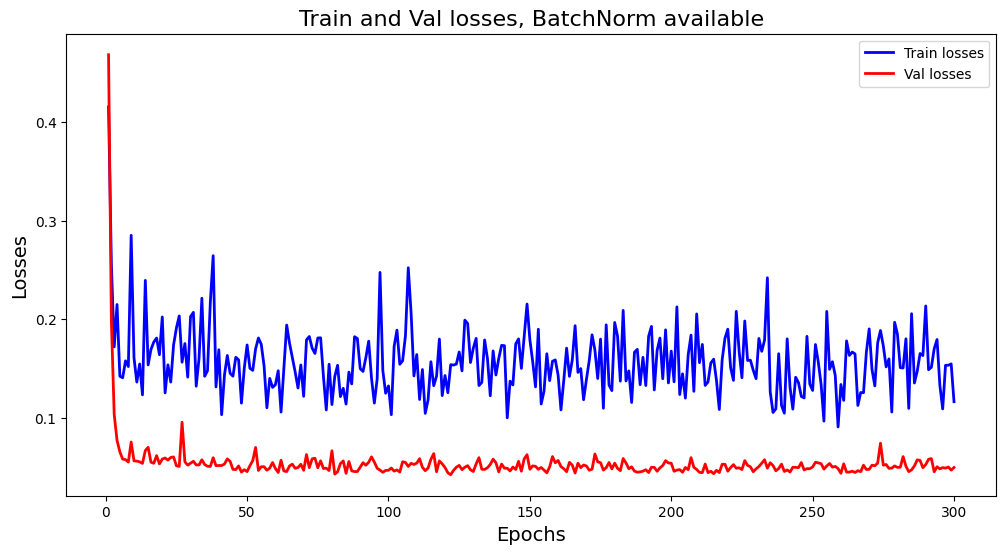

 Epoch: 49 | Train Loss: 0.1023 | Val Loss 0.0565
 Epoch: 99 | Train Loss: 0.0908 | Val Loss 0.0448
 Epoch: 149 | Train Loss: 0.0678 | Val Loss 0.0446
 Epoch: 199 | Train Loss: 0.0722 | Val Loss 0.0431
 Epoch: 249 | Train Loss: 0.0661 | Val Loss 0.0526


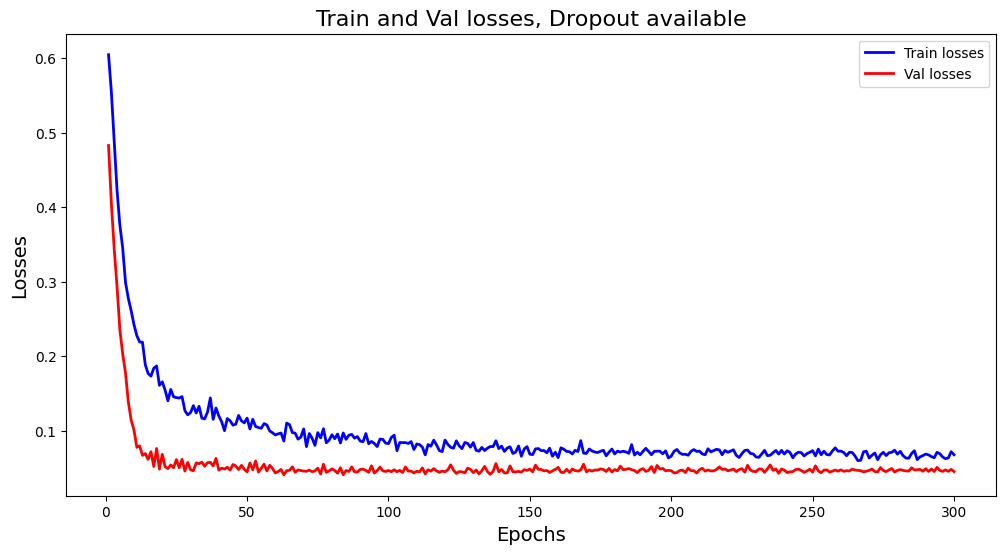

 Epoch: 49 | Train Loss: 0.2603 | Val Loss 0.0730
 Epoch: 99 | Train Loss: 0.2121 | Val Loss 0.0824
 Epoch: 149 | Train Loss: 0.2156 | Val Loss 0.0667
 Epoch: 199 | Train Loss: 0.2315 | Val Loss 0.0615
 Epoch: 249 | Train Loss: 0.1666 | Val Loss 0.0694


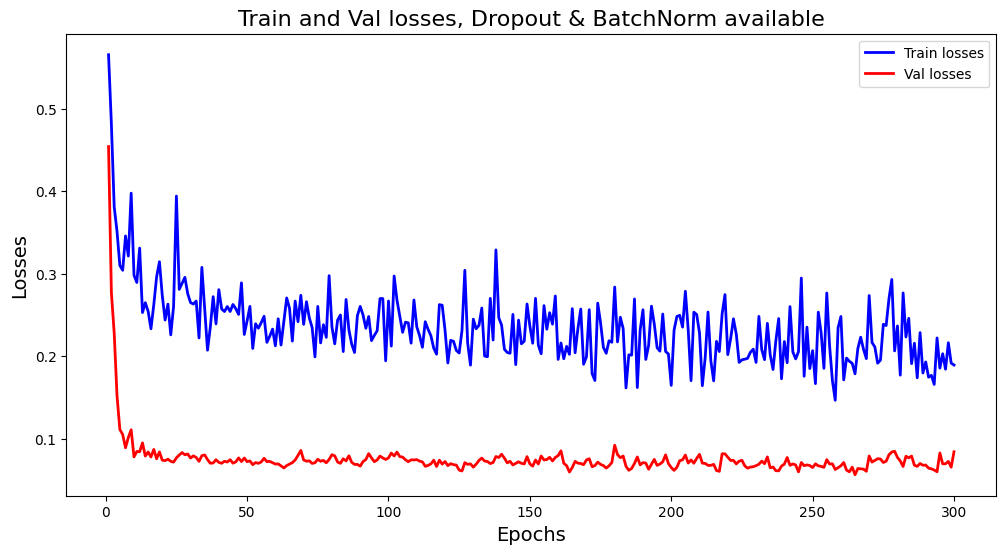

In [ ]:
results_2 = train_and_evaluate_models(train_dataloader_2, val_dataloader_2)

 Epoch: 49 | Train Loss: 0.0117 | Val Loss 0.0131
 Epoch: 99 | Train Loss: 0.0097 | Val Loss 0.0104
 Epoch: 149 | Train Loss: 0.0102 | Val Loss 0.0109
 Epoch: 199 | Train Loss: 0.0099 | Val Loss 0.0122
 Epoch: 249 | Train Loss: 0.0099 | Val Loss 0.0108


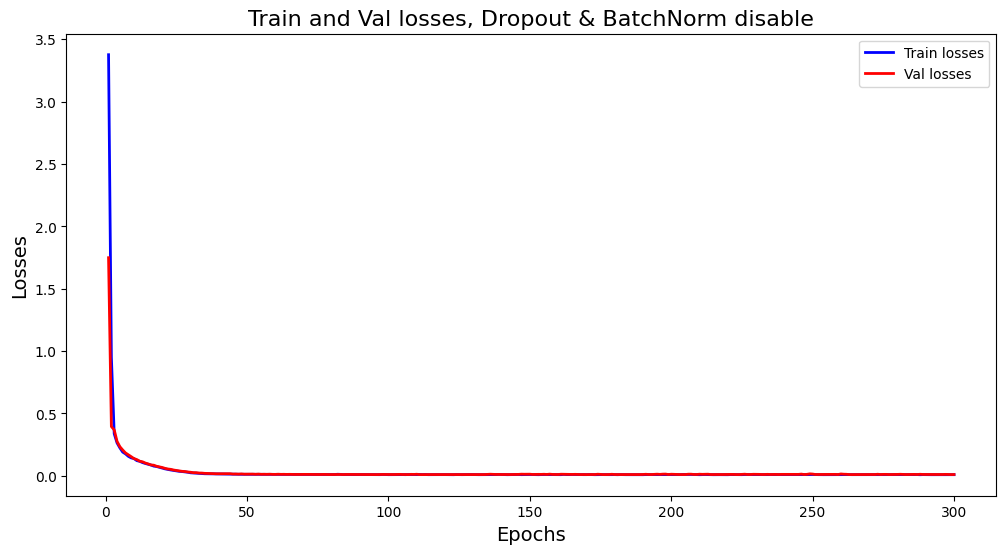

 Epoch: 49 | Train Loss: 0.1987 | Val Loss 0.0402
 Epoch: 99 | Train Loss: 0.1673 | Val Loss 0.0338
 Epoch: 149 | Train Loss: 0.1725 | Val Loss 0.0209
 Epoch: 199 | Train Loss: 0.1195 | Val Loss 0.0342
 Epoch: 249 | Train Loss: 0.1320 | Val Loss 0.0660


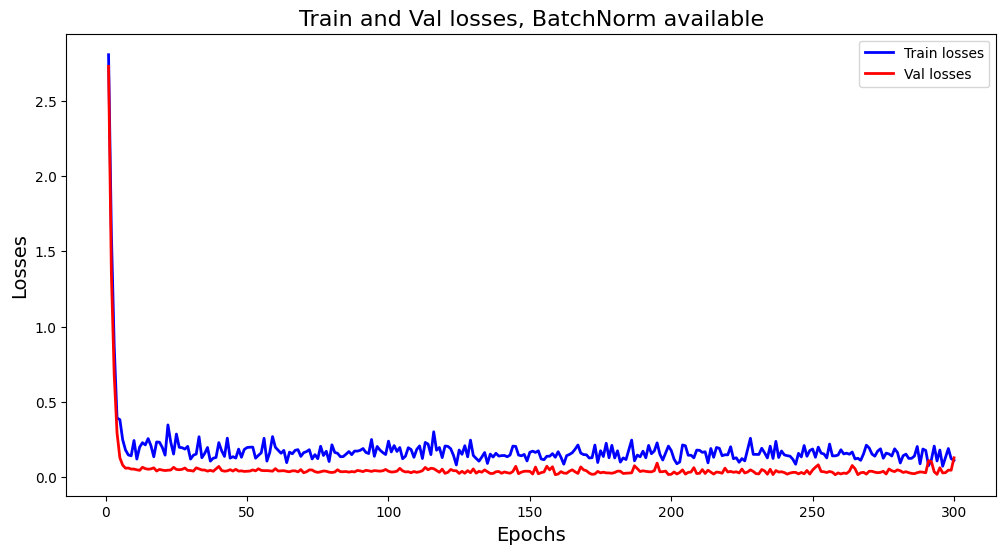

 Epoch: 49 | Train Loss: 0.1837 | Val Loss 0.0538
 Epoch: 99 | Train Loss: 0.1716 | Val Loss 0.0416
 Epoch: 149 | Train Loss: 0.1352 | Val Loss 0.0264
 Epoch: 199 | Train Loss: 0.1282 | Val Loss 0.0186
 Epoch: 249 | Train Loss: 0.1044 | Val Loss 0.0189


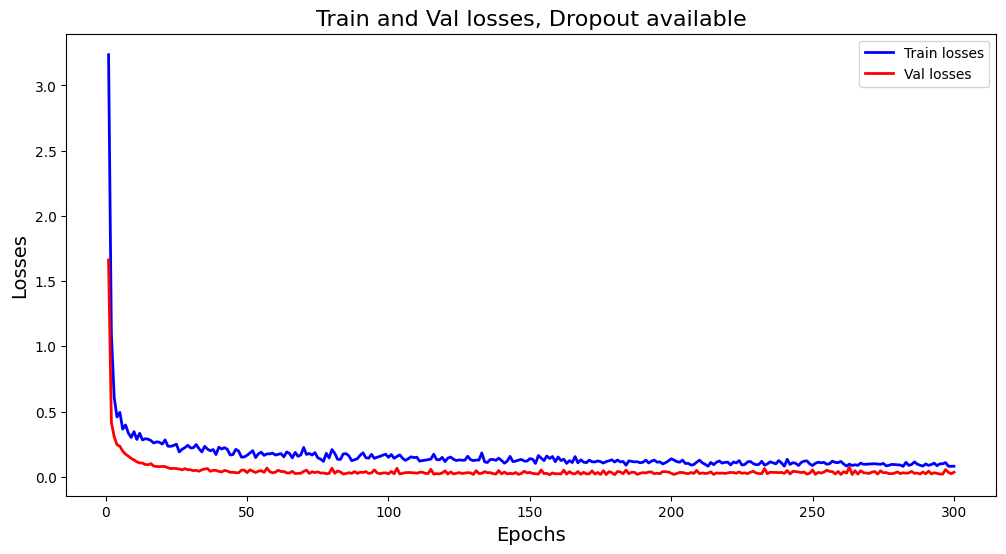

 Epoch: 49 | Train Loss: 0.2852 | Val Loss 0.1772
 Epoch: 99 | Train Loss: 0.2210 | Val Loss 0.1702
 Epoch: 149 | Train Loss: 0.2734 | Val Loss 0.1802
 Epoch: 199 | Train Loss: 0.2466 | Val Loss 0.1086
 Epoch: 249 | Train Loss: 0.1993 | Val Loss 0.1043


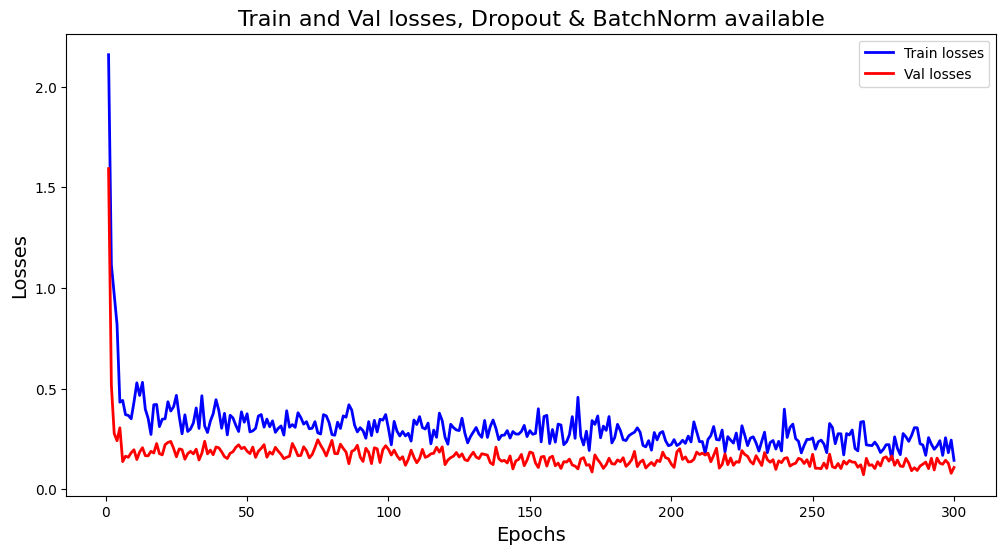

In [ ]:
results_3 = train_and_evaluate_models(train_dataloader_3, val_dataloader_3)

In [ ]:
for name, loss in results_1.items():
    print(f"{name}: Final Loss = {loss[1][-1]:.4f}")

No Dropout, No BatchNorm: Final Loss = 0.0385
BatchNorm Only: Final Loss = 0.0886
Dropout Only: Final Loss = 0.0624
BatchNorm + Dropout: Final Loss = 0.1711


In [ ]:
for name, loss in results_2.items():
    print(f"{name}: Final Loss = {loss[1][-1]:.4f}")

No Dropout, No BatchNorm: Final Loss = 0.0454
BatchNorm Only: Final Loss = 0.0495
Dropout Only: Final Loss = 0.0449
BatchNorm + Dropout: Final Loss = 0.0840


In [ ]:
for name, loss in results_3.items():
    print(f"{name}: Final Loss = {loss[1][-1]:.4f}")

No Dropout, No BatchNorm: Final Loss = 0.0107
BatchNorm Only: Final Loss = 0.1283
Dropout Only: Final Loss = 0.0357
BatchNorm + Dropout: Final Loss = 0.1083


Вывод

В случае экспериментов с разным *batch_size* мы можем видеть, что маленькие значения приводят к высокой дисперсии градиентов, а следовательно в значительных осцилляциях loss'а.

Во втором эксперименте мы можем наблюдать заметные осцилляции лосса при использовании *BatchNorm*. Это может быть связано с нестабильностью параметров $α$ и $γ$ и неоптимальным значением momentum. При отключении *BatchNorm* и использовании *Dropout* ситуация улучшается, поскольку соседние нейроны лучше адаптируются к структуре данных и наличию шума в данных. При использовании *BatchNorm* и *Dropout* одновременно картина loss'а улучшается, но всё равно видна некоторая проблема с неоптимальным подбором $α$, $γ$ и momentum в  *BatchNorm*.  Самый лучший результат мы можем наблюдать вовсе без использования *BatchNorm* и *Dropout*. Это может быть связано с тем, что в данной задаче статистики активаций слоев не испытывают значительных колебаний, и дополнительная нормализация лишь вносит лишнюю нестабильность. Кроме того, модель может быть достаточно устойчивой к переобучению без необходимости использования *Dropout*.


